In [21]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
# Display settings
sns.set(style="whitegrid")
plt.style.use("ggplot")

In [23]:
# Load Dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)


In [24]:
# Basic structure and Info
print("Shape of dataset:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
df.head()

Shape of dataset: (891, 12)

Data Types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


 **Step 1: Data Exploration**

•	Rows: 891 passengers

•	Columns: 12 features

•	Target Variable: Survived (0 = No, 1 = Yes)

•	The dataset contains both numerical and categorical features.

•	Missing values observed in Age, Cabin, and Embarked.


**UNIVARIATE ANALYSIS**

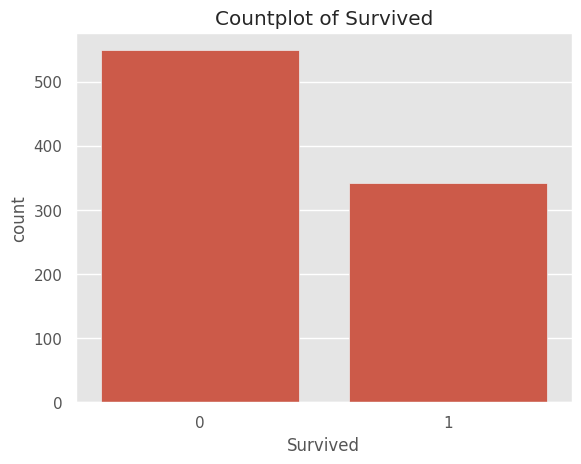

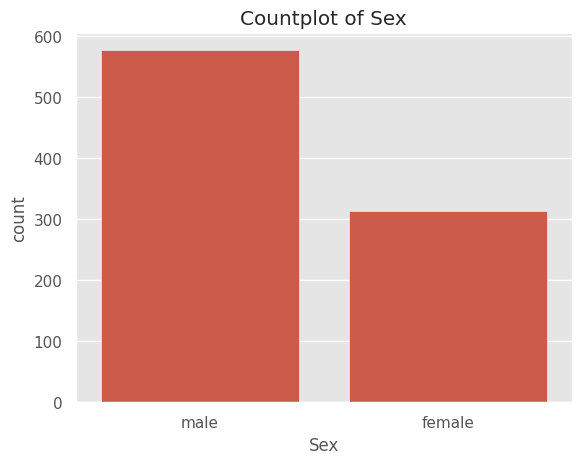

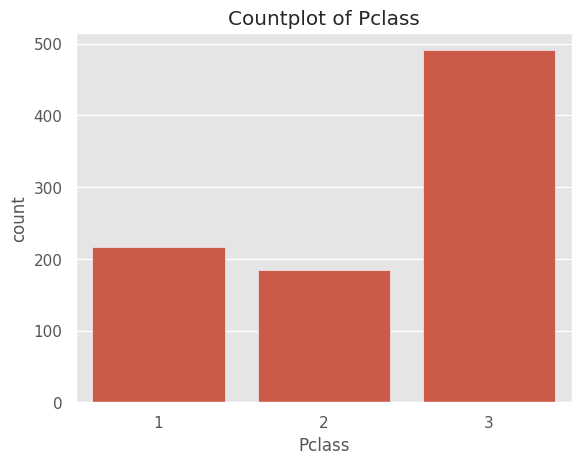

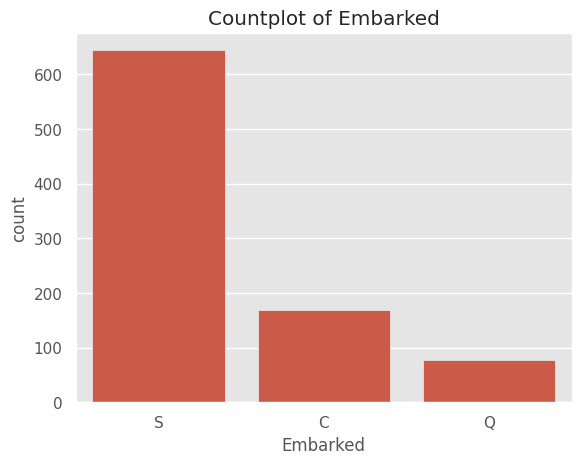

In [25]:
# Count plots for categorical columns
categorical_cols = ['Survived', 'Sex', 'Pclass', 'Embarked']
for col in categorical_cols:
  sns.countplot(x=col, data=df)
  plt.title(f'Countplot of {col}')
  plt.show()

**Survived**
* The dataset is imbalanced: more passengers did not survive (0) than those who did (1).
* Survival rate appears to be around 38%

**Sex**
* There are more male passengers than female.

**Pclass**
* Most passengers traveled in 3rd class, followed by 1st and 2nd.
* Class might be linked to socioeconomic status, possibly affecting survival.  

**Embarked**
* Majority of passengers embarked from Southampton (S).
* Cherbourg (C) and Queenstown (Q) were less common.






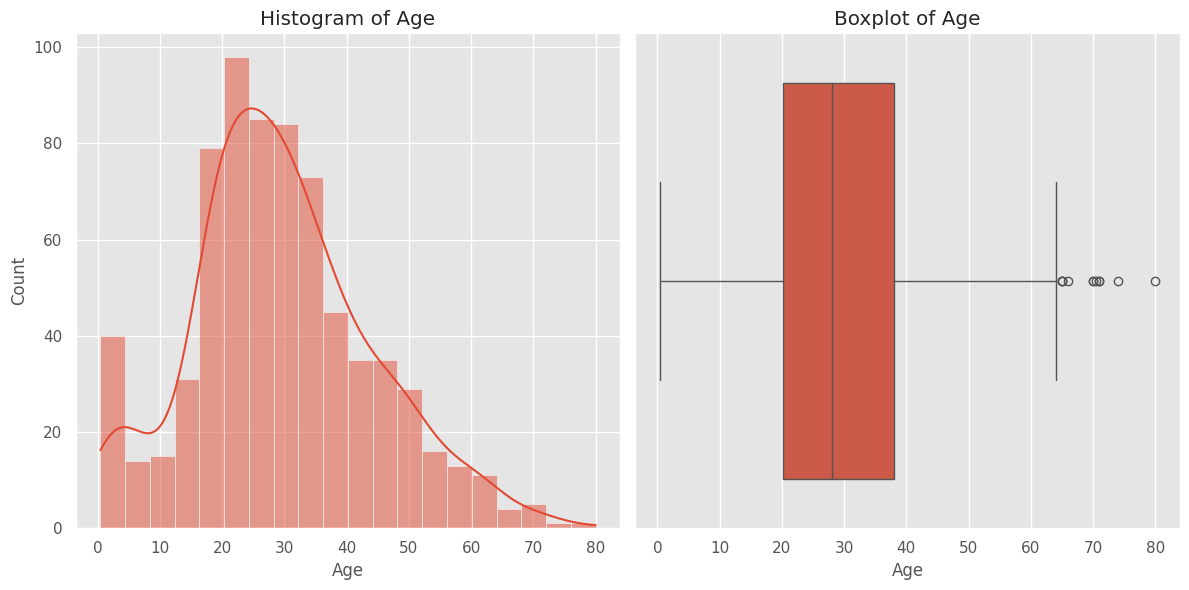

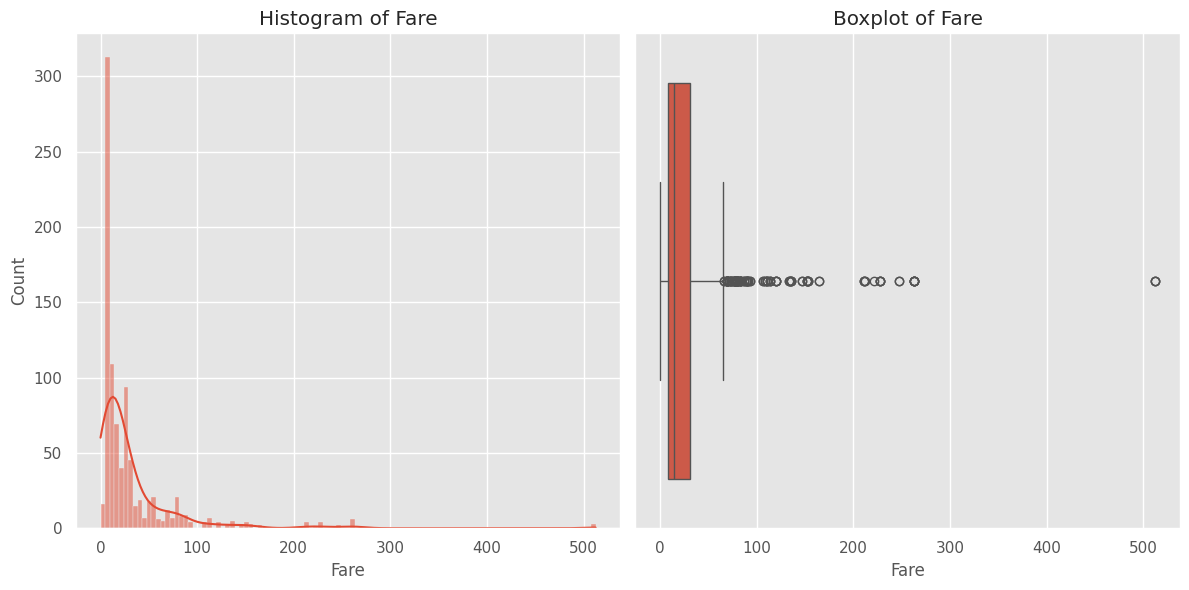

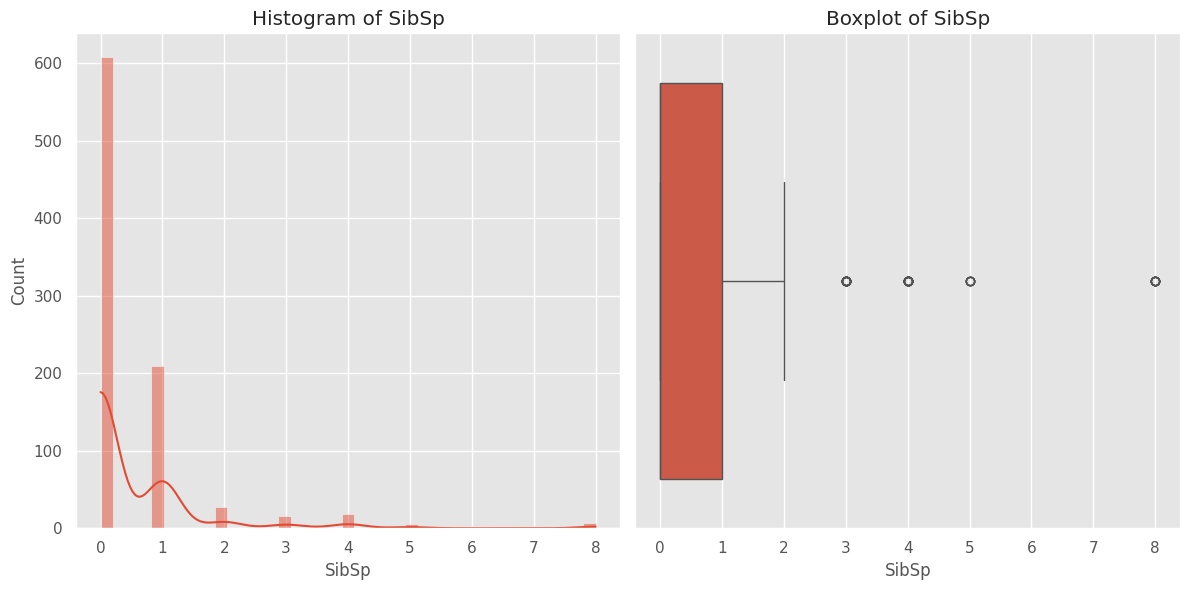

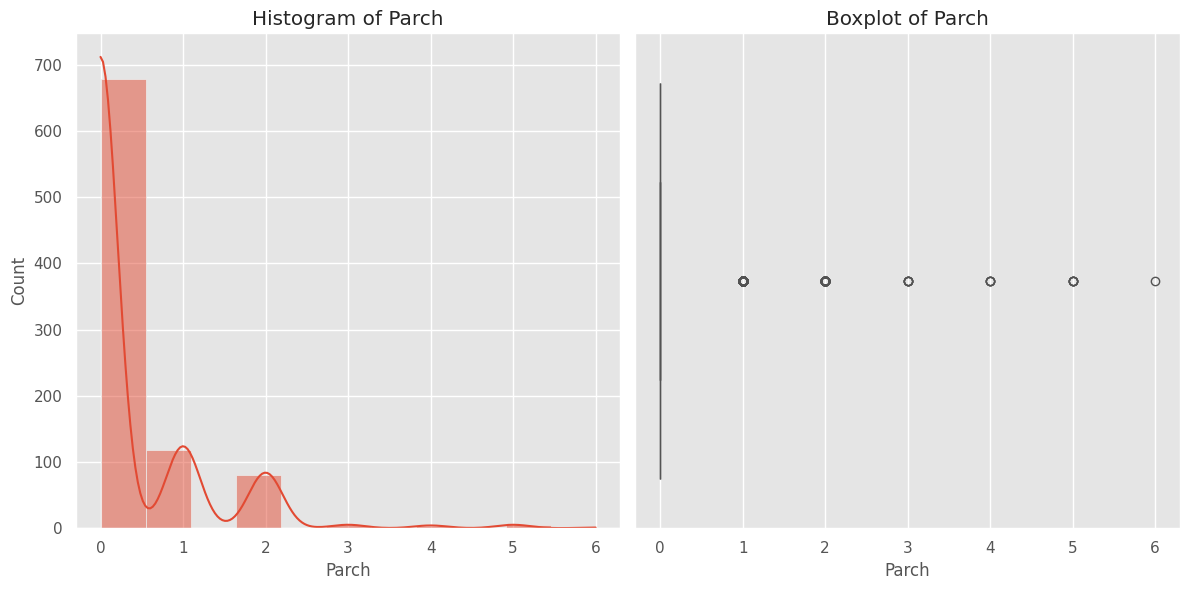

In [26]:
# Histogram and Boxplots for numerical columns
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch']

for col in numerical_cols:
  fig, axes = plt.subplots(1, 2, figsize=(12, 6))

  sns.histplot(df[col].dropna(), kde=True, ax=axes[0])
  axes[0].set_title(f'Histogram of {col}')

  sns.boxplot(x=df[col], ax=axes[1])
  axes[1].set_title(f'Boxplot of {col}')

  plt.tight_layout()
  plt.show()

**Age**
* Distribution is right-skewed.
* Most passengers were between 20 and 40 years old.  
* There are some missing values here.  
* A few children and elderly passengers are present.  

**Fare**
* Highly right-skewed with some passengers paying very high fares.
* Many fares fall below $100, but some outliers paid over $500.  
* Consider log transformation if using Fare in modeling.

**SibSp(Siblings/Spouses abroad)**
* Most passengers had 0 siblings/spouses aboard.
* A few had 1–3; very few had more (max is 8).

**Parch(Parents/Children abroad)**
* Majority had no parents or children aboard.
* Some had 1 or 2; outliers had up to 6.

**BIVARIATE ANALYSIS**


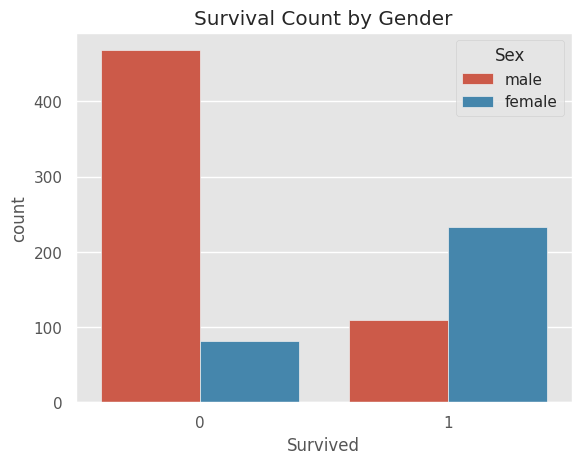

In [27]:
# Survival by Sex
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title('Survival Count by Gender')
plt.show()

**Survivial by Sex**
* Females had a much higher survival rate than males.
* Gender played a significant role in survival, likely due to the “women and children first” policy.

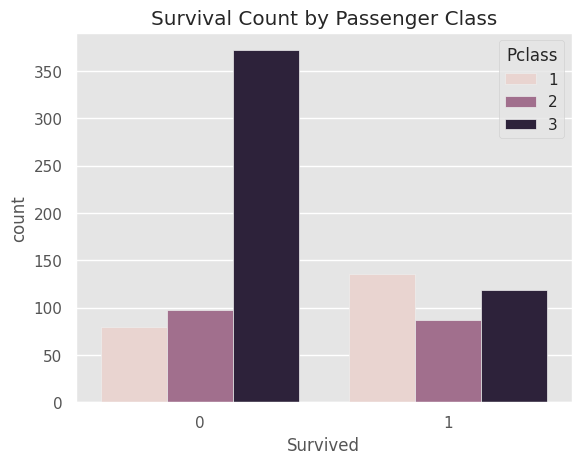

In [28]:
# Survival by Pclass
sns.countplot(x='Survived', hue='Pclass', data=df)
plt.title('Survival Count by Passenger Class')
plt.show()

**Survival by Pclass**
* 1st class passengers had a higher chance of survival.
* Survival decreased in lower classes, especially 3rd class.

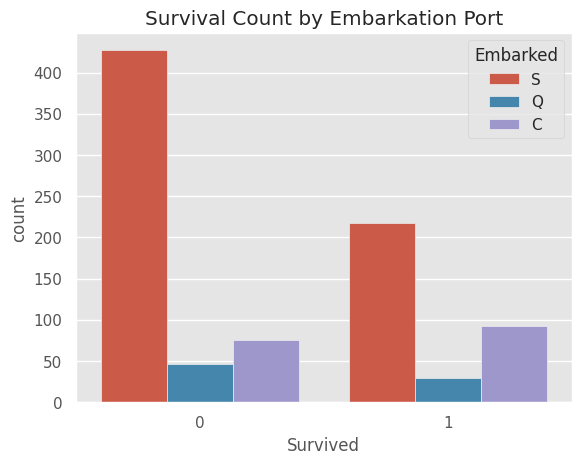

In [29]:
# Survival by Embarked
sns.countplot(x='Survived', hue='Embarked', data=df)
plt.title('Survival Count by Embarkation Port')
plt.show()

**Survival by Embarked**
* Passengers from Cherbourg (C) had the highest survival rate.
* Southampton (S) had the lowest, possibly tied to class distribution.

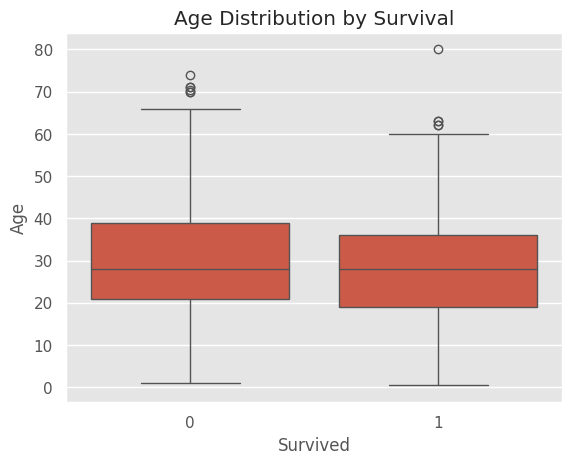

In [30]:
# Age vs Survived (Boxplot)
sns.boxplot(x='Survived', y='Age', data=df)
plt.title('Age Distribution by Survival')
plt.show()

**Age vs Survived**
* Children (especially under 10) had a higher chance of survival.
* Younger adults had mixed outcomes; many elderly passengers didn’t survive.

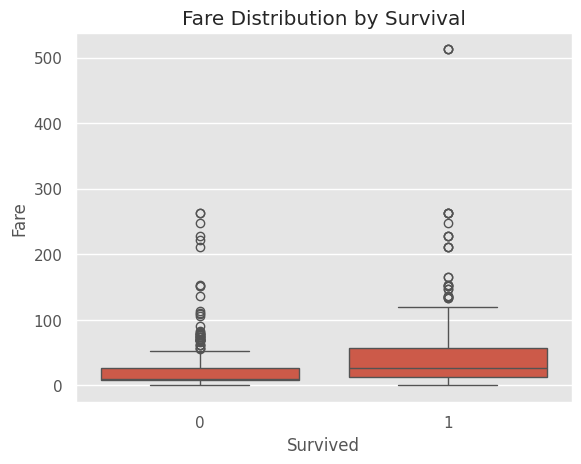

In [31]:
# Fare vs Survived (Boxplot)
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title('Fare Distribution by Survival')
plt.show()

**Fare vs Survived**
* Higher fares correlate with better survival chances.
* Again, tied to class—higher-paying passengers were more likely in 1st class.

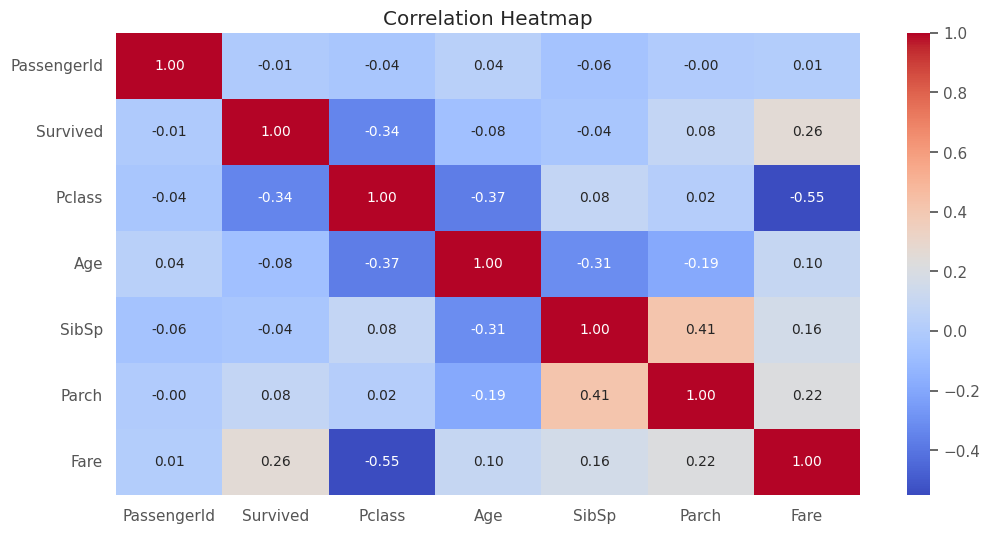

In [32]:
# Correlation Heatmap
# Only numerical features
plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

**Correlation Heatmap**
* Pclass is negatively correlated with Survived (higher class → more likely to survive).
* Fare and Sex also show a good correlation with survival.
* SibSp and Parch show low correlation on their own.

**MULTIVARIATE ANALYSIS / PAIRPLOT**

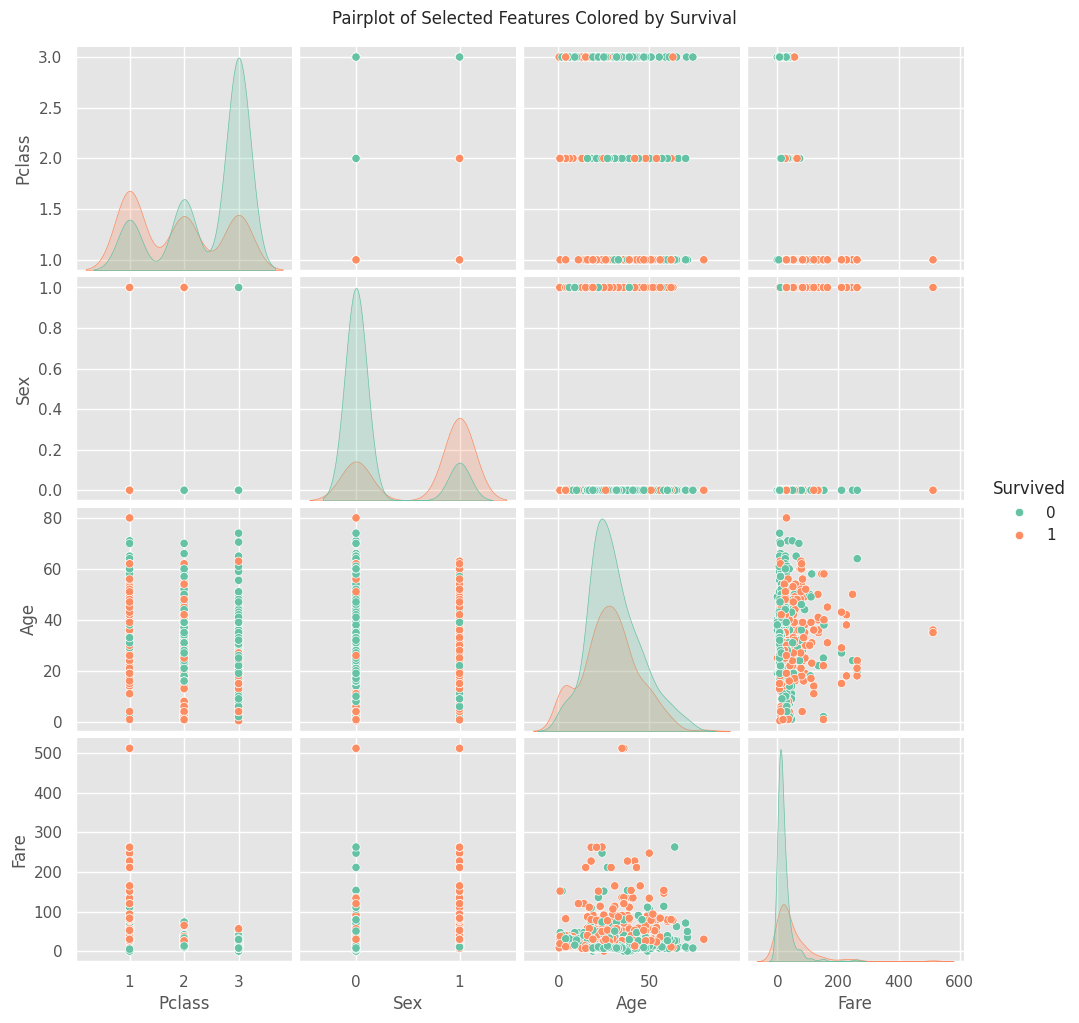

In [33]:
# Pairplot
selected_cols = ['Survived', 'Pclass', 'Sex', 'Age', 'Fare']
# Convert 'Sex' to numeric for plotting
df_pair = df[selected_cols].dropna()
df_pair['Sex'] = df_pair['Sex'].map({'male': 0, 'female': 1})

sns.pairplot(df_pair, hue='Survived', palette='Set2')
plt.suptitle('Pairplot of Selected Features Colored by Survival', y=1.02)
plt.show()

**Multivariate Analysis / Pairplot**
* Survived vs Age vs Fare: Survivors generally cluster around moderate fares and younger ages, though some high-fare older passengers also survived.
* Pclass effect is visible: 1st class passengers (higher fare, generally older) show higher survival.
* Sex + Age + Survived: Female passengers across age groups have a higher survival cluster than males.
* Fare overlaps exist, but higher fare passengers show stronger survival patterns.
* Clusters of non-survivors are visible in low fare, low age, and male-dominated regions.

**ADVANCED VISUALS**

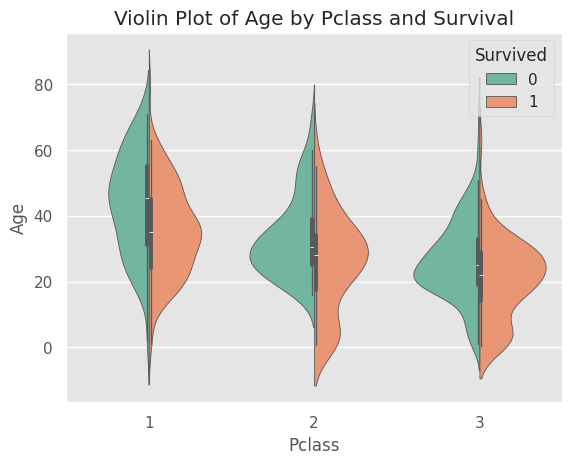

In [34]:
# Violin Plot - Age vs Pclass vs Survived
sns.violinplot(x='Pclass', y='Age', hue='Survived', data=df, split=True, palette='Set2')
plt.title('Violin Plot of Age by Pclass and Survival')
plt.show()

* In 1st class, survivors tend to be older than in other classes.
* In 3rd class, most passengers were younger and few survived.

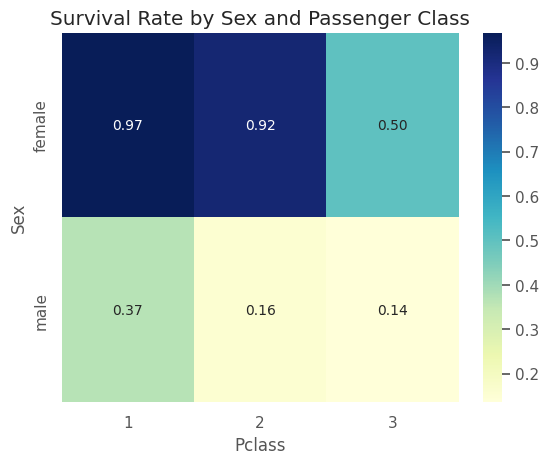

In [35]:
# Categorical Heatmap - Survival Rate pivot table
# Create pivot table
heatmap_data = df.pivot_table(index='Sex', columns='Pclass', values='Survived', aggfunc='mean')

# Heatmap
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Survival Rate by Sex and Passenger Class')
plt.show()

* Females in 1st and 2nd class had the highest survival rates.
* Males in 3rd class had the lowest.
* Confirms strong interaction between Sex and Pclass on survival.

**Summary of Findings**

**Survival Rate**: About **38%** of passengers survived. The dataset is imbalanced.

**Gender Impact**: Females had a significantly higher survival rate than males.

**Class Difference**: Passengers in 1st class had the highest survival chances, especially females.

**Embarked Port**: Those who embarked from Cherbourg had better survival rates—possibly linked to class.

**Age Factor**: Children and young adults were more likely to survive; elderly survival was lower.

**Fare Patterns**: Higher fares correlated with higher survival, again tied to class and cabin location.
**Multivariate Analysis** showed that:
  - Sex + Class together had a strong interaction with survival.
  - Younger females in 1st/2nd class had the best survival odds.

**Heatmaps and pairplots** revealed strong correlations between survival and Sex, Pclass, and Fare.

This analysis highlights how social structure, wealth, and demographics influenced survival on the Titanic.